## Marker Detection Tutorial

This tutorial demonstrates how to use ImFusion's marker detection capabilities through Python bindings. Marker detection is essential for computer vision applications such as camera calibration, pose estimation, and augmented reality.

In [8]:
import imfusion as imf
from imfusion import vision # Marker detection is in the vision module

import numpy as np
import matplotlib.pyplot as plt

In [9]:
# Load image. The image also contains a CameraCalibrationDataComponent with the camera calibration
images = imf.load("data/marker_detection.imf")

In [10]:
# Set marker configuration manually
charuco_config = vision.marker_configuration.CharucoBoardInfo()
charuco_config.grid_size = (5, 7)  # 5x7 grid
charuco_config.cell_size = 16.0  # 16 mm cell size
charuco_config.marker_size = 8.0  # 8 mm marker size
charuco_config.dictionary = vision.marker_configuration.ArucoDictionary.DICT_6X6_250

# Save configuration to file
vision.marker_configuration.save_marker(charuco_config, "MarkerConfig.xml")

# We could also directly load the marker configuration from file if it is already available
# charuco_config = vision.marker_configuration.load_marker("MarkerConfig.xml")


Detection results:
  Image 1:
    Object points: 24
    Image points: 24


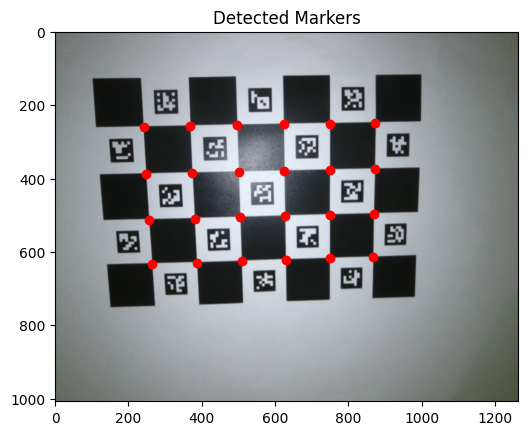

In [11]:
# Detect markers
result = vision.detect_markers(images[0], marker_configuration=charuco_config)
        
print(f"\nDetection results:")        
for i, (obj_points, img_points) in enumerate(zip(result.object_points, result.image_points)):
    print(f"  Image {i+1}:")
    print(f"    Object points: {len(obj_points)}")
    print(f"    Image points: {len(img_points)}")

# Display image with detected markers
arr = np.array(images[0][0])
plt.imshow(arr)
# Plot detected image points
for point in result.image_points[0]:
    plt.plot(point[0], point[1], "ro")
plt.title("Detected Markers")
plt.show()


In [12]:
# Since the input images contained camera calibration information we can also estimate the pose
if result.poses:
    # Show camera calibration
    calibration = images[0].components.camera_calibration
    print(f"Camera calibration:")
    print(f"  Intrinsic matrix:\n {calibration.intrinsic_matrix}")
    print(f"  Distortion coefficients: {calibration.distortion}")

    for i, pose in enumerate(result.poses):
        print(f"\nPose {i+1}:")
        print(f"  Translation: [{pose[0,3]:.2f}, {pose[1,3]:.2f}, {pose[2,3]:.2f}]")
                
        # Extract rotation matrix
        rotation = pose[:3, :3]
        print(f"  Rotation matrix:\n {rotation}")
                

Camera calibration:
  Intrinsic matrix:
 [[1.04587472e+03 0.00000000e+00 5.89864030e+02]
 [0.00000000e+00 1.04463817e+03 5.06467597e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
  Distortion coefficients: [-0.02198458  0.02584169 -0.0006321   0.00221558  0.        ]

Pose 1:
  Translation: [53.49, 29.89, 143.12]
  Rotation matrix:
 [[-0.02034205 -0.99881248  0.04426995]
 [-0.98984424  0.02635094  0.13969254]
 [-0.14069321 -0.04097872 -0.98920481]]
